In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as stats
from matplotlib import pyplot as plt

In [80]:
df = pd.read_csv('../processed_data/processed_data.csv')
df.columns

Index(['Date', 'Basin', 'VMAX12', 'MSLP12', 'POT12', 'VMPI12', 'VGRAD0-6',
       'VGRAD6-12', 'VMAX36', 'ONI', 'logVMAX12', 'logMSLP12', 'logPOT12',
       'logVMAX36', 'logVMPI12'],
      dtype='object')

In [ ]:
df["logONIplus2"] = np.log(df["ONI"] + 2)
df["VACC"] = (df["VGRAD6-12"] - df["VGRAD0-6"]) / 6
min(df["POT12"])

8.0

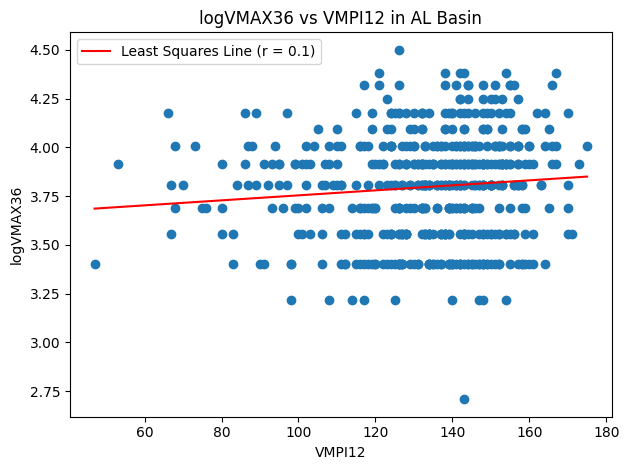

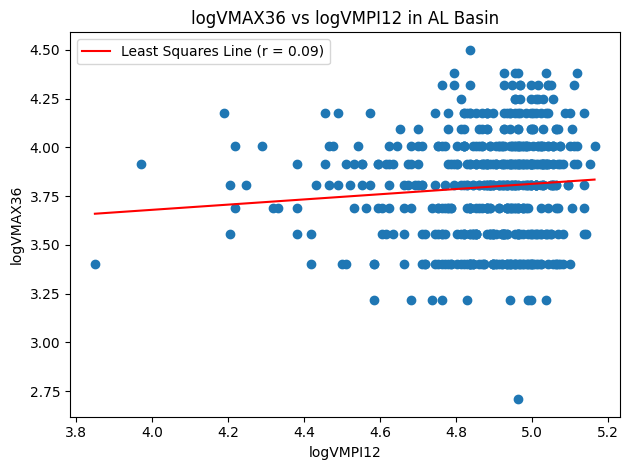

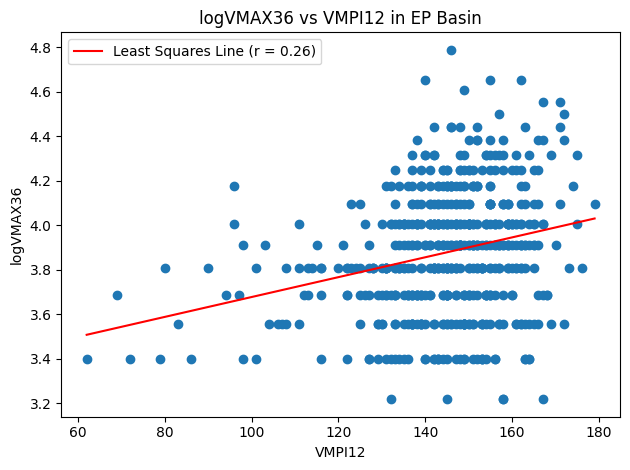

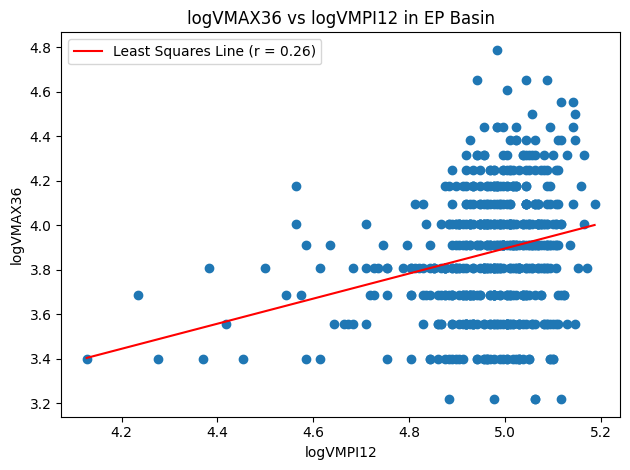

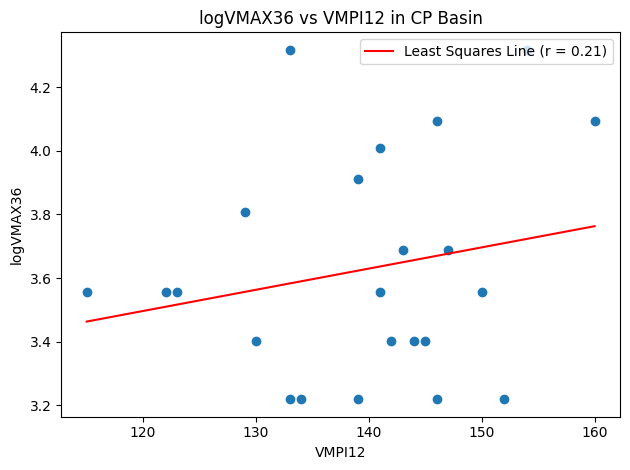

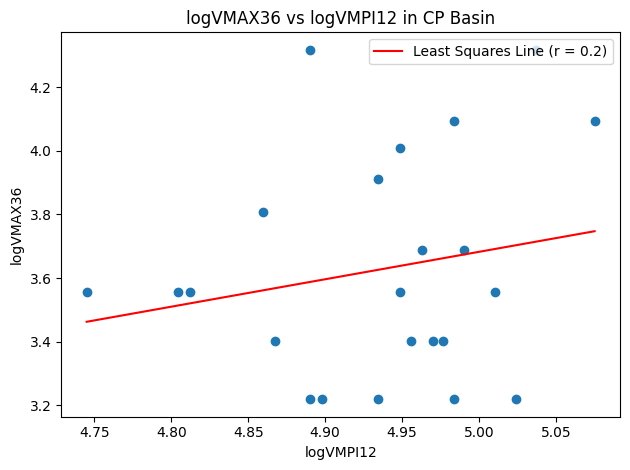

In [85]:
basins = ["AL", "EP", "CP"]
# cols = ["ONI", "logONIplus2"]
# cols = ["VGRAD6-12", "VGRAD0-6", "VACC"]
# cols = ["MSLP12", "logMSLP12"]
cols = ["VMPI12", "logVMPI12"]
col_to_pred = "logVMAX36"
for basin in basins:
    basin_df = df[df["Basin"] == basin]
    for col in cols:
        plt.title(f"{col_to_pred} vs {col} in {basin} Basin")
        plt.xlabel(col)
        plt.ylabel(col_to_pred)
        plt.scatter(basin_df[col], basin_df[col_to_pred])
        reg = stats.linregress((basin_df[col]), basin_df[col_to_pred])
        domain = np.linspace(min(basin_df[col]), max(basin_df[col]), 200)
        plt.plot(domain, reg[0]*domain + reg[1], color='red', label=f'Least Squares Line (r = {np.round(reg[2], 2)})')
        plt.legend()
        plt.tight_layout()
        plt.show()

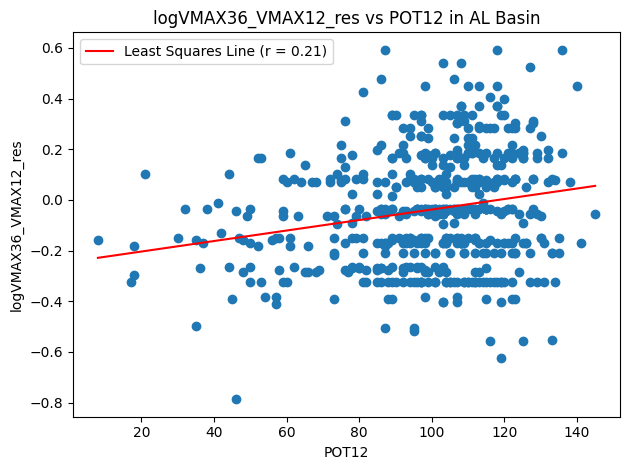

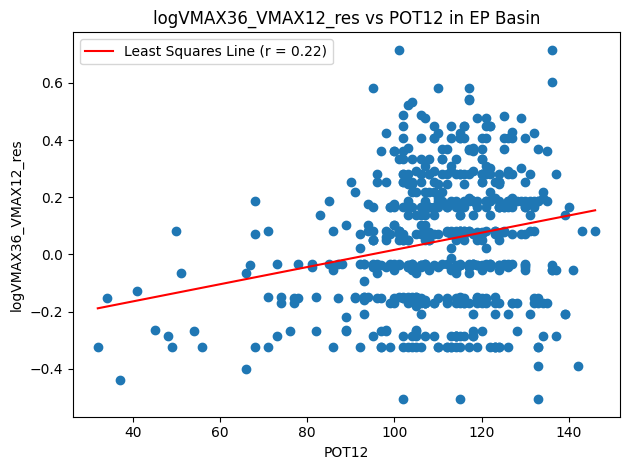

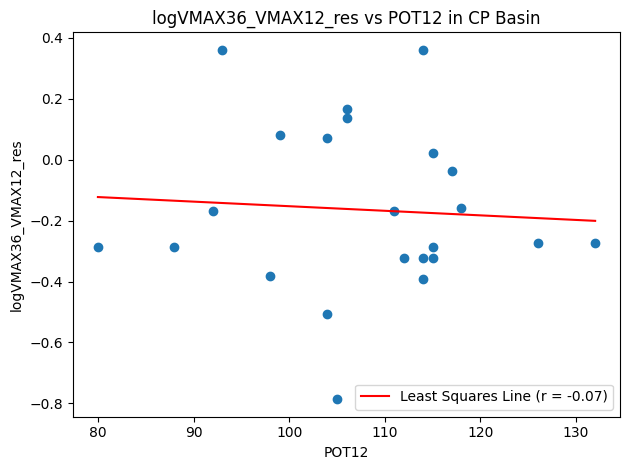

In [76]:
col_to_pred = "logVMAX36"
col_to_control = "VMAX12"
reg = stats.linregress((df[col_to_control]), df[col_to_pred])
pred_col = f"{col_to_pred}_{col_to_control}_pred"
df[pred_col] = reg[0]*df[col_to_control] + reg[1]
res_col = f"{col_to_pred}_{col_to_control}_res"
df[res_col] = df[col_to_pred] - df[pred_col]
col_to_pred = res_col
cols = ["POT12"]
for basin in basins:
    basin_df = df[df["Basin"] == basin]
    for col in cols:
        plt.title(f"{col_to_pred} vs {col} in {basin} Basin")
        plt.xlabel(col)
        plt.ylabel(col_to_pred)
        plt.scatter(basin_df[col], basin_df[col_to_pred])
        reg = stats.linregress((basin_df[col]), basin_df[col_to_pred])
        domain = np.linspace(min(basin_df[col]), max(basin_df[col]), 200)
        plt.plot(domain, reg[0]*domain + reg[1], color='red', label=f'Least Squares Line (r = {np.round(reg[2], 2)})')
        plt.legend()
        plt.tight_layout()
        plt.show()

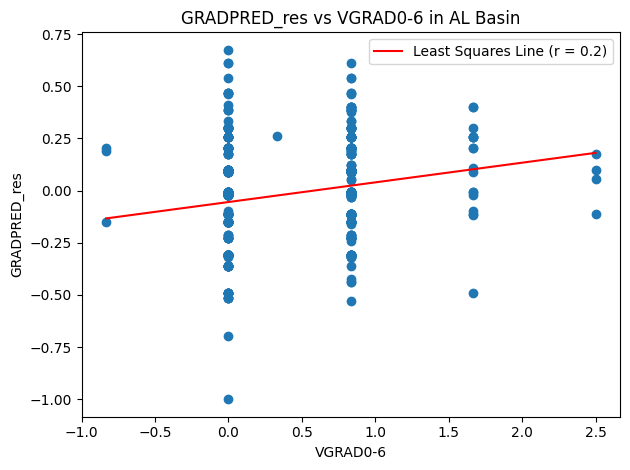

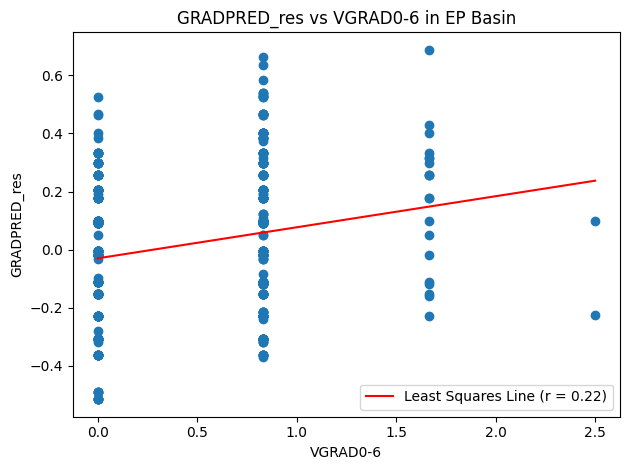

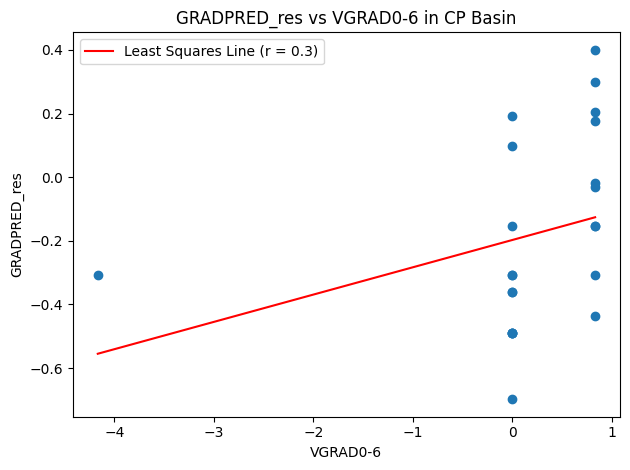

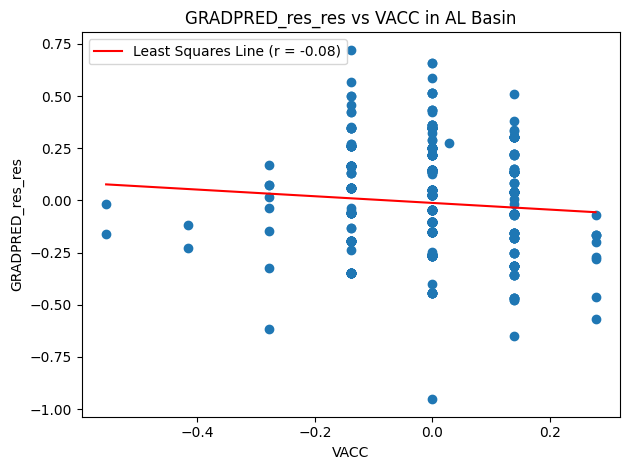

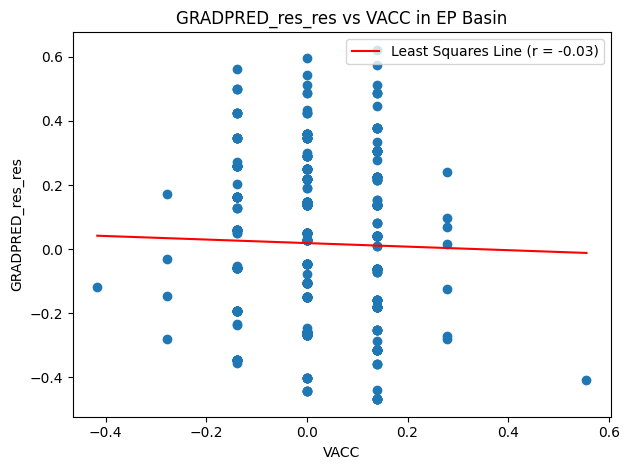

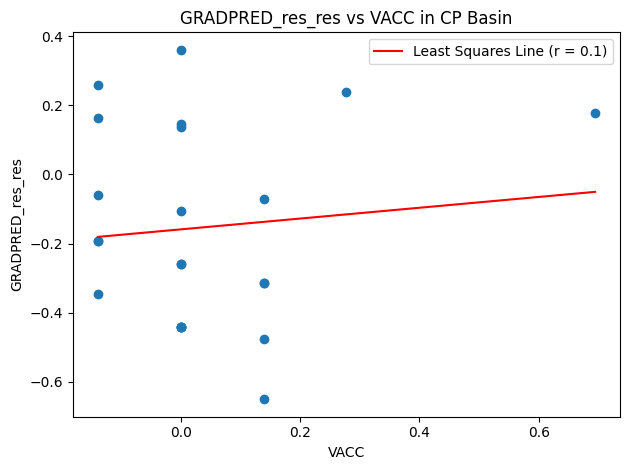

In [61]:
col_to_pred = "logVMAX36"
reg = stats.linregress((df["VGRAD6-12"]), df[col_to_pred])
df["logVMAX36_GRADPRED"] = reg[0]*df["VGRAD6-12"] + reg[1]
df["GRADPRED_res"] = df["logVMAX36"] - df["logVMAX36_GRADPRED"]
col_to_pred = "GRADPRED_res"
cols = ["VGRAD0-6"]
for basin in basins:
    basin_df = df[df["Basin"] == basin]
    for col in cols:
        plt.title(f"{col_to_pred} vs {col} in {basin} Basin")
        plt.xlabel(col)
        plt.ylabel(col_to_pred)
        plt.scatter(basin_df[col], basin_df[col_to_pred])
        reg = stats.linregress((basin_df[col]), basin_df[col_to_pred])
        domain = np.linspace(min(basin_df[col]), max(basin_df[col]), 200)
        plt.plot(domain, reg[0]*domain + reg[1], color='red', label=f'Least Squares Line (r = {np.round(reg[2], 2)})')
        plt.legend()
        plt.tight_layout()
        plt.show()
reg = stats.linregress((df["VGRAD0-6"]), df[col_to_pred])
df[f"{col_to_pred}_GRAD06PRED"] = reg[0]*df["VGRAD0-6"] + reg[1]
df[f"{col_to_pred}_res"] = df[col_to_pred] - df[f"{col_to_pred}_GRAD06PRED"]
col_to_pred = "GRADPRED_res_res"
cols = ["VACC"]
for basin in basins:
    basin_df = df[df["Basin"] == basin]
    for col in cols:
        plt.title(f"{col_to_pred} vs {col} in {basin} Basin")
        plt.xlabel(col)
        plt.ylabel(col_to_pred)
        plt.scatter(basin_df[col], basin_df[col_to_pred])
        reg = stats.linregress((basin_df[col]), basin_df[col_to_pred])
        domain = np.linspace(min(basin_df[col]), max(basin_df[col]), 200)
        plt.plot(domain, reg[0]*domain + reg[1], color='red', label=f'Least Squares Line (r = {np.round(reg[2], 2)})')
        plt.legend()
        plt.tight_layout()
        plt.show()